# Machine Learning 46 : **t-SNE (t-Distributed Stochastic Neighbour Embedding)**

## **1. Introduction**

### **What is t-SNE?**

**t-SNE (t-Distributed Stochastic Neighbor Embedding)** is a **non-linear dimensionality reduction** and **data visualization** technique.
It transforms **high-dimensional data** (e.g., 100+ features) into a **low-dimensional space** (usually 2D or 3D) while **preserving the local structure** — meaning points that are close in high-dimensional space remain close in 2D or 3D space.

In simple terms:
t-SNE helps you **see** and **understand** patterns, clusters, or relationships in complex data.

### **Who developed it and when?**

t-SNE was developed by **Laurens van der Maaten** and **Geoffrey Hinton** in **2008**.

### **Why is it widely used in data visualization?**

* It creates **visually interpretable clusters**.
* Excellent for **high-dimensional datasets** like:

  * **Images (MNIST)**
  * **Text embeddings (NLP)**
  * **Genetic data**
* Often used for **exploratory data analysis (EDA)** to **see structure or hidden patterns**.


## **2. Concept and Intuition**

### **How t-SNE helps in visualization**

t-SNE reduces high-dimensional data (say, 100D) to 2D or 3D in such a way that:

* Points that are **similar** in high-dimensional space are placed **close together**.
* Points that are **different** are placed **far apart**.

It focuses on **local relationships**, not global geometry.

### **Preserving Local Structure**

t-SNE measures **pairwise similarity** between points in high-dimensional space using **probabilities**.
Then, it tries to reproduce those probabilities in low-dimensional space.

So:

* Neighbors stay neighbors.
* Distant points remain far.

### **Difference Between t-SNE and PCA**

| Feature       | PCA                           | t-SNE                      |
| ------------- | ----------------------------- | -------------------------- |
| Type          | Linear                        | Non-linear                 |
| Goal          | Capture maximum variance      | Preserve local structure   |
| Output        | Axes are principal components | Axes have no clear meaning |
| Best for      | Global structure              | Local clusters             |
| Visualization | Sometimes unclear clusters    | Clear cluster separation   |


## **3. Mathematical Foundation**

Let’s simplify the math intuition:

### **Step 1: Probability Distribution in High-Dimensional Space**

t-SNE converts distances between points into **conditional probabilities** —
probability that point ( x_j ) would pick ( x_i ) as a neighbor.

$$
p_{j|i} = \frac{\exp(-||x_i - x_j||^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-||x_i - x_k||^2 / 2\sigma_i^2)} $$

Then make it **symmetric**:

$$ p_{ij} = \frac{p_{i|j} + p_{j|i}}{2N} $$

### **Step 2: Probability Distribution in Low-Dimensional Space**

Similarly, define a probability ( q_{ij} ) in the low-dimensional (2D or 3D) space:

$$q_{ij} = \frac{(1 + ||y_i - y_j||^2)^{-1}}{\sum_{k \neq l}(1 + ||y_k - y_l||^2)^{-1}}$$

Here, a **Student-t distribution** (heavy-tailed) is used instead of Gaussian to handle “crowding” in low dimensions.

### **Step 3: Minimize the Difference (KL Divergence)**

t-SNE minimizes the **Kullback-Leibler (KL) divergence** between these two distributions:

$$C = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

The lower the KL divergence, the more similar the two distributions are → better visualization.

### **Step 4: Optimization**

This cost function ( C ) is minimized using **gradient descent** to update the positions ( y_i ).


## **4. Steps of the t-SNE Algorithm**

1. **Compute pairwise similarities in high-dimensional space**

   * Calculate distances and convert them into probabilities $$( p_{ij} ).$$

2. **Define similarities in low-dimensional space**

   * Compute $$( q_{ij} )$$ using the Student-t distribution.

3. **Minimize the KL Divergence**

   * Measure how different the two probability distributions are.

4. **Optimization (Gradient Descent)**

   * Adjust points in 2D/3D to minimize KL divergence.

## **5. Parameters and Hyperparameters**

| Parameter         | Description                                                                                | Typical Range |
| ----------------- | ------------------------------------------------------------------------------------------ | ------------- |
| **perplexity**    | Controls the balance between local/global structure. Think of it as “number of neighbors.” | 5–50          |
| **learning_rate** | Step size for optimization. Too low = slow, too high = chaos.                              | 100–1000      |
| **n_iter**        | Number of iterations for convergence.                                                      | ≥ 1000        |
| **n_components**  | Output dimensions (2 for 2D, 3 for 3D).                                                    | 2 or 3        |
| **random_state**  | For reproducibility.                                                                       | any integer   |


## **7. Advantages and Limitations**

### **Advantages**

* Excellent for **visualizing clusters**.
* Works well on **non-linear, complex data**.
* Preserves **local neighborhood structure**.

### **Limitations**

* **Computationally expensive** for large datasets.
* **Does not preserve global distances** (the scale of distances is meaningless).
* **Non-deterministic** (results can differ slightly each run).
* **Cannot be used for new/unseen data** (not a transform method like PCA).

### **When to Use**

* For **exploratory visualization** of complex data.
* To **inspect embeddings** from models (e.g., word2vec, BERT, autoencoders).

### **When Not to Use**

* For **feature reduction before training**.
* When you need **interpretability of axes or distances**.


## **8. Practical Applications**

| Domain                | Example Use                                             |
| --------------------- | ------------------------------------------------------- |
| **NLP**               | Visualizing word embeddings or sentence representations |
| **Computer Vision**   | Visualizing image embeddings from CNNs                  |
| **Genomics**          | Exploring gene expression data                          |
| **Anomaly Detection** | Finding unusual clusters or outliers                    |
| **Model Debugging**   | Checking learned feature separability                   |

## **9. Conclusion**

* **t-SNE** is a **powerful visualization tool** for high-dimensional data.
* It preserves **local relationships** but not **global geometry**.
* Ideal for **exploring and understanding clusters** in complex datasets.

### **Comparison Summary**

| Technique | Type       | Best For                    | Notes                       |
| --------- | ---------- | --------------------------- | --------------------------- |
| **PCA**   | Linear     | Global variance             | Fast and interpretable      |
| **t-SNE** | Non-linear | Local cluster visualization | Great for small/medium data |
| **UMAP**  | Non-linear | Local + global structure    | Faster and scalable         |



In [1]:
from sklearn.datasets import load_iris
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

In [3]:
# Apply t-SNE
# newer scikit-learn versions expect `max_iter` instead of `n_iter`
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, random_state=42)
X_embedded = tsne.fit_transform(X)

In [4]:
# Convert to DataFrame for plotting
df = pd.DataFrame()
df["Dim1"] = X_embedded[:,0]
df["Dim2"] = X_embedded[:,1]
df["Target"] = y

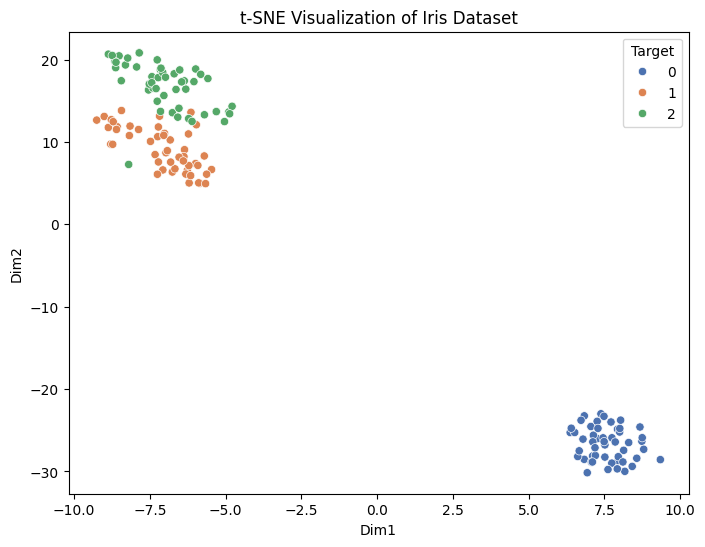

In [5]:
# Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(x="Dim1", y="Dim2", hue="Target", palette="deep", data=df)
plt.title("t-SNE Visualization of Iris Dataset")
plt.show()

In [6]:
import plotly.express as px
from sklearn.datasets import make_classification

X, y = make_classification(
    n_features=6,
    n_classes=3,
    n_samples=1500,
    n_informative=2,
    random_state=5,
    n_clusters_per_class=1,
)


fig = px.scatter_3d(x=X[:, 0], y=X[:, 1], z=X[:, 2], color=y, opacity=0.8)
fig.show()

We have a 3D plot of the data; you can also visualize the data in a 2D chart by using the Plotly Express scatter function.

We will now apply the `PCA algorithm` on the dataset to return two PCA components. The fit_transform learns and transforms the dataset at the same time.  

In [7]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# **PCA Visualization Python**
We can now visualize the results by displaying two PCA components on a scatter plot. 

x: First component
y: Second companion
color: target variable.
We have also used the update_layout function to add a title and rename the x-axis and y-axis.

In [8]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)
tsne.kl_divergence_

1.127296805381775

# t-SNE Visualization Python
Similar to PCA, we will visualize two t-SNE components on a scatter plot. 

In [9]:
fig = px.scatter(x=X_tsne[:, 0], y=X_tsne[:, 1], color=y)
fig.update_layout(
    title="t-SNE visualization of Custom Classification dataset",
    xaxis_title="First t-SNE",
    yaxis_title="Second t-SNE",
)
fig.show()

# Kullback-Leibler (KL) divergence

The Kullback-Leibler (KL) divergence is a measure of how one probability distribution diverges from a second, expected probability distribution. In the context of t-SNE, it's used as a cost function to measure the dissimilarity between the high-dimensional distribution of points (the p_ij's) and the low-dimensional distribution (the q_ij's).

In [10]:
import numpy as np
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
# Load the diamonds dataset from seaborn
diamonds = sns.load_dataset('diamonds')

In [12]:
# Prepare the data for t-SNE
X = diamonds[['carat', 'depth', 'table', 'x', 'y', 'z']]

In [13]:
# Standardize the data
X = (X - X.mean()) / X.std()

In [14]:
# Perform t-SNE
tsne = TSNE(n_components=2, random_state=0)
X_2d = tsne.fit_transform(X)

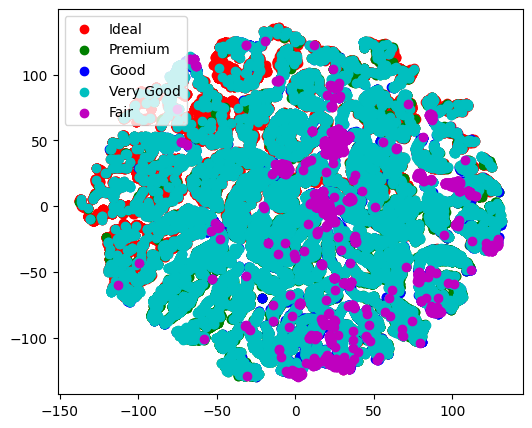

In [15]:
# Plot the results
plt.figure(figsize=(6, 5))
colors = 'r', 'g', 'b', 'c', 'm', 'y', 'k', 'w', 'orange', 'purple'
for i, c, label in zip(range(10), colors, diamonds['cut'].unique()):
    plt.scatter(X_2d[diamonds['cut'] == label, 0], X_2d[diamonds['cut'] == label, 1], c=c, label=label)
plt.legend()
plt.show()
